In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,27.0,North,Relatively New,NaN,NaN,6500.0,0,0,0,0,0,1,110,1625.000000
1,flat,dlf new town heights,sector 86,1.26,6114.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,5.0,West,Moderately Old,1930.0,NaN,NaN,0,1,0,0,1,1,113,687.000000
2,flat,oriental valley chs,sector 9a,1.50,9091.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,8.0,NaN,Relatively New,NaN,NaN,1650.0,0,0,0,0,0,0,8,412.500000
3,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,19.0,NaN,Moderately Old,NaN,1410.0,NaN,0,0,0,0,0,1,63,705.000000
4,flat,microtek greenburg,sector 86,1.45,9797.0,1480.0,Built Up area: 1480 (137.5 sq.m.)Carpet area: ...,3,2,3,8.0,North-East,Relatively New,NaN,1480.0,1050.0,0,0,0,0,0,2,72,493.333333


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

#### built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

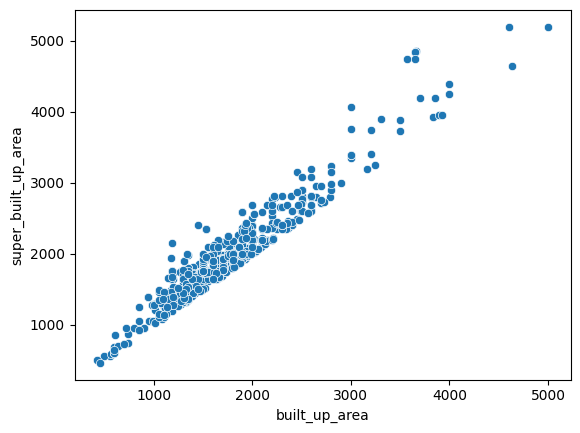

In [7]:
sns.scatterplot(data = df , x = df['built_up_area'], y = df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

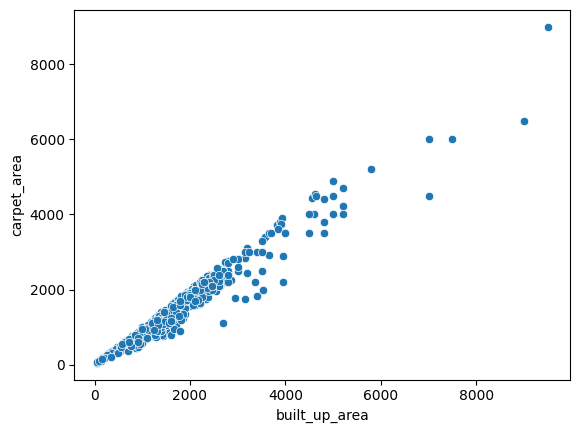

In [8]:
sns.scatterplot(df , x = df['built_up_area'], y = df['carpet_area'])

In [10]:
df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio


In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(531, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [14]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [15]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [16]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [17]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
9,flat,shree vardhman victoria,sector 70,1.65,8462.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,4,3,1.0,North,Relatively New,1950.0,NaN,1267.00,0,1,0,0,0,2,167,650.000000
25,flat,emaar gurgaon greens,sector 102,1.35,8182.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,5.0,North-West,Relatively New,1650.0,NaN,1022.58,0,1,0,0,0,1,119,550.000000
34,flat,dlf new town heights,sector 90,1.95,7151.0,2727.0,Super Built up area 2727(253.35 sq.m.)Carpet a...,4,4,3+,24.0,North-East,Relatively New,2727.0,NaN,2200.00,0,1,1,0,0,1,174,681.750000
46,flat,bestech park view ananda,sector 81,1.35,7542.0,1790.0,Super Built up area 1790(166.3 sq.m.)Carpet ar...,3,3,3+,10.0,North-East,Moderately Old,1790.0,NaN,1130.00,0,0,1,0,0,0,72,596.666667
54,flat,corona optus,sector 37c,1.25,8929.0,1400.0,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,3,2.0,South-East,Relatively New,1735.0,NaN,1400.00,1,0,0,0,0,1,49,466.666667


In [18]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\virat\AppData\Local\Temp\ipykernel_18744\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\virat\AppData\Local\Temp\ipykernel_18744\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [19]:
df.update(sbc_df)

In [20]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [21]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [22]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,dlf new town heights,sector 86,1.26,6114.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,5.0,West,Moderately Old,1930.0,NaN,NaN,0,1,0,0,1,1,113,687.000000
6,flat,bptp terra,sector 37d,1.45,8007.0,1811.0,Super Built up area 1811(168.25 sq.m.),3,3,3,9.0,North-East,Relatively New,1811.0,NaN,NaN,0,0,0,0,0,1,107,603.666667
11,flat,bptp astaire gardens,sector 70a,0.97,6585.0,1473.0,Super Built up area 1480(137.5 sq.m.),3,3,3+,1.0,West,Relatively New,1480.0,NaN,NaN,0,0,0,0,1,1,149,491.000000
12,flat,signature global city,sector 37d,0.80,8421.0,950.0,Super Built up area 950(88.26 sq.m.),2,2,2,2.0,NaN,Undefined,950.0,NaN,NaN,0,0,0,0,0,1,42,475.000000
14,flat,puri diplomatic greens,sector 111,5.25,11667.0,4500.0,Super Built up area 4500(418.06 sq.m.),4,6,3+,7.0,East,Relatively New,4500.0,NaN,NaN,0,1,0,0,0,0,134,1125.000000


In [23]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\virat\AppData\Local\Temp\ipykernel_18744\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\virat\AppData\Local\Temp\ipykernel_18744\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [24]:
df.update(sb_df)

In [25]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [26]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [27]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,27.0,North,Relatively New,NaN,NaN,6500.0,0,0,0,0,0,1,110,1625.0
2,flat,oriental valley chs,sector 9a,1.50,9091.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,8.0,NaN,Relatively New,NaN,NaN,1650.0,0,0,0,0,0,0,8,412.5
18,flat,nul,gwal pahari,0.56,6054.0,925.0,Carpet area: 925 (85.94 sq.m.),2,2,1,11.0,NaN,Old Property,NaN,NaN,925.0,0,0,0,0,0,0,0,462.5
20,flat,parsvnath green ville,sector 48,2.50,12821.0,1950.0,Carpet area: 1950 (181.16 sq.m.),4,5,3,1.0,South-East,Moderately Old,NaN,NaN,1950.0,0,0,0,0,1,0,49,487.5
23,flat,chanderlok society,sector 28,0.90,7235.0,1244.0,Carpet area: 1244 (115.57 sq.m.),4,2,3+,1.0,NaN,Old Property,NaN,NaN,1244.0,0,0,0,0,0,1,0,311.0


In [28]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\virat\AppData\Local\Temp\ipykernel_18744\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\virat\AppData\Local\Temp\ipykernel_18744\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [29]:
df.update(c_df)

In [30]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

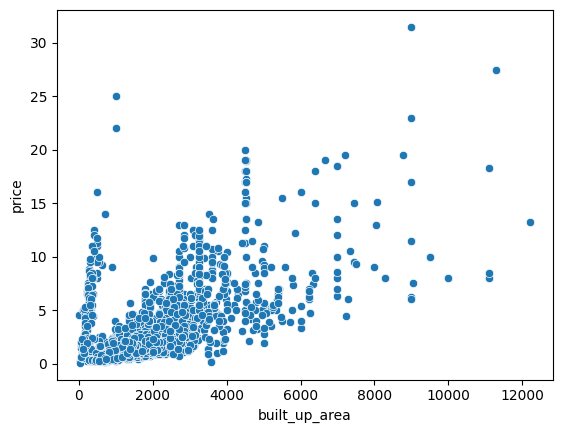

In [32]:
sns.scatterplot(df , x = df['built_up_area'],y = df['price'])

In [33]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [34]:
anamoly_df.sample(5)

,price,area,built_up_area
2554,2.65,1400.0,1800.0
1577,2.80,2047.0,1971.0
1568,3.50,1350.0,1350.0
356,5.30,1935.0,1935.0
609,6.50,2332.0,299.0


In [35]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [36]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

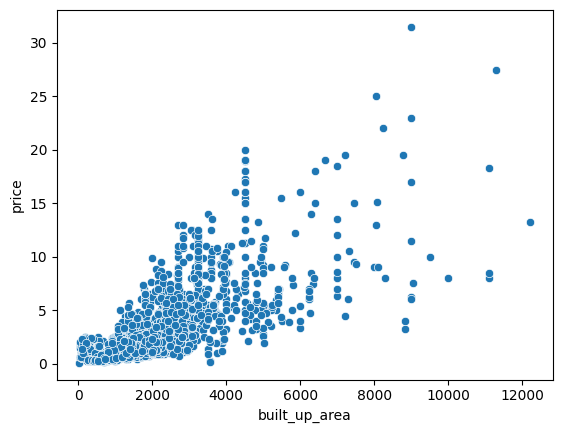

In [37]:
sns.scatterplot(df , x = df['built_up_area'],y = df['price'])

In [38]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [39]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,4,5,3+,27.0,North,Relatively New,7222.0,0,0,0,0,0,1,110
1,flat,dlf new town heights,sector 86,1.26,6114.0,3,3,3,5.0,West,Moderately Old,1747.0,0,1,0,0,1,1,113
2,flat,oriental valley chs,sector 9a,1.50,9091.0,4,3,3+,8.0,NaN,Relatively New,1833.0,0,0,0,0,0,0,8
3,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,2,2,3,19.0,NaN,Moderately Old,1410.0,0,0,0,0,0,1,63
4,flat,microtek greenburg,sector 86,1.45,9797.0,3,2,3,8.0,North-East,Relatively New,1480.0,0,0,0,0,0,2,72


In [40]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

#### floorNum

In [41]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
79,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,1,0
302,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,9
487,house,Vipul Tatvam Villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,1,21
867,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,1,0
901,house,Ansal Sushant Lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,1,59
1116,house,Ansal Sushant Lok Plots4.1 ★,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0
1148,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,1,0
1157,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,1,28
2350,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,1,0
2512,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,1,0


In [42]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [43]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\virat\AppData\Local\Temp\ipykernel_18744\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [44]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [45]:
1011/df.shape[0]

0.2843881856540084

#### facing

<Axes: ylabel='count'>

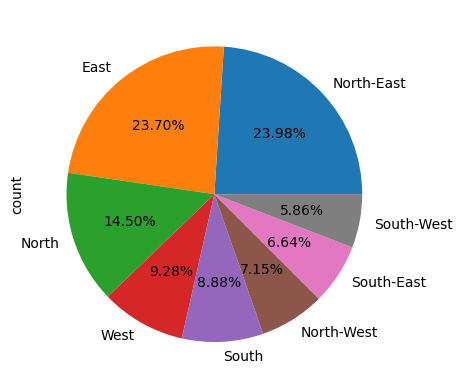

In [46]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [47]:
df.drop(columns=['facing'],inplace=True)

In [49]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [51]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2350,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [52]:
df.drop(index = [2350] , inplace = True)

In [53]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

#### agePossession

In [54]:
df['agePossession'].value_counts()

agePossession
Relatively New        1605
New Property           557
Moderately Old         545
Undefined              431
Old Property           293
Under Construction     123
Name: count, dtype: int64

In [55]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,flat,hcbs sports ville,sohna road,0.30,4011.0,2,2,2,3.0,Undefined,743.0,0,0,0,0,0,1,0
8,flat,vatika sovereign park,sector 99,3.20,9922.0,4,4,0,5.0,Undefined,3225.0,0,0,0,0,0,1,23
12,flat,signature global city,sector 37d,0.80,8421.0,2,2,2,2.0,Undefined,860.0,0,0,0,0,0,1,42
16,flat,trisara our homes 3,sohna road,0.38,6312.0,2,2,2,1.0,Undefined,602.0,0,0,0,0,0,1,0
39,flat,gls arawali homes,sohna road,0.32,6723.0,2,1,0,0.0,Undefined,476.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,flat,signature global city 81,sector 81,0.80,14652.0,2,2,2,4.0,Undefined,607.0,1,0,0,0,0,1,36
3509,house,independent,sector 103,2.25,6367.0,3,5,3+,10.0,Undefined,3534.0,0,0,0,0,0,1,0
3512,flat,trisara our homes 3,sohna road,0.40,4479.0,2,2,2,1.0,Undefined,900.0,0,0,0,0,0,1,0
3519,flat,emaar palm gardens,sector 83,1.80,9474.0,3,4,0,9.0,Undefined,1900.0,0,0,0,0,0,1,55


In [56]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [57]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [58]:
df['agePossession'].value_counts()

agePossession
Relatively New        1782
New Property           635
Moderately Old         586
Old Property           331
Under Construction     125
Undefined               95
Name: count, dtype: int64

In [59]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)
df['agePossession'].value_counts()

agePossession
Relatively New        1798
New Property           657
Moderately Old         593
Old Property           342
Under Construction     125
Undefined               39
Name: count, dtype: int64

In [61]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [62]:
df['agePossession'].value_counts()

agePossession
Relatively New        1814
New Property           657
Moderately Old         616
Old Property           342
Under Construction     125
Name: count, dtype: int64

In [63]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [64]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [65]:
df.shape

(3554, 18)